# **Instalação e Importação de Bibliotecas, Módulos e Pacotes**

In [1]:
!pip install shap lime -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Importação de todas as bibliotecas que serão utilizadas
import pandas as pd
from scipy.io import arff
import numpy as np
import seaborn as sns
import json
from openai import OpenAI
import shap
import lime
from lime import lime_tabular
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# **Leitura do Dataset utilizado para treinar os Modelos**

In [3]:
# Define o dataset que será utilizado, disponível em: https://www.kaggle.com/datasets/hassan06/nslkdd/

df = pd.read_csv("./KDDTrain+_20Percent.txt", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
# Coloca os nomes das features/colunas
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label",
    "difficulty_level"
]

df.columns = columns

print("Dataset (Linhas/Colunas <-> Entradas/Features):", df.shape)
df.head(5)

Dataset (Linhas/Colunas <-> Entradas/Features): (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# **Tratamento dos dados**

In [5]:
print("Dataset (Linhas/Colunas <-> Entradas/Features):", df.shape)
df.head(5)

Dataset (Linhas/Colunas <-> Entradas/Features): (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
# Verifica se existe (e quantos são) valores nulos em cada features/coluna
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [7]:
# Remove dados duplicados e linhas com valores faltando
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [8]:
print("Dataset (Linhas/Colunas <-> Entradas/Features):", df.shape)
df.head(5)

Dataset (Linhas/Colunas <-> Entradas/Features): (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [9]:
# Codificação para as features/colunas com valores não numéricos
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [10]:
for col in categorical_cols:
    print(f"{col} categories: {df[col].cat.categories.tolist()}")

protocol_type categories: ['icmp', 'tcp', 'udp']
service categories: ['IRC', 'X11', 'Z39_50', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'hostnames', 'http', 'http_443', 'http_8001', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'red_i', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tim_i', 'time', 'urh_i', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois']
flag categories: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']


In [11]:
for col in categorical_cols:
    df[col] = df[col].cat.codes

In [12]:
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [13]:
df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,1,19,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0,20
1,0,2,41,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0,15
2,0,1,46,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1,19
3,0,1,22,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0,21
4,0,1,22,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,21


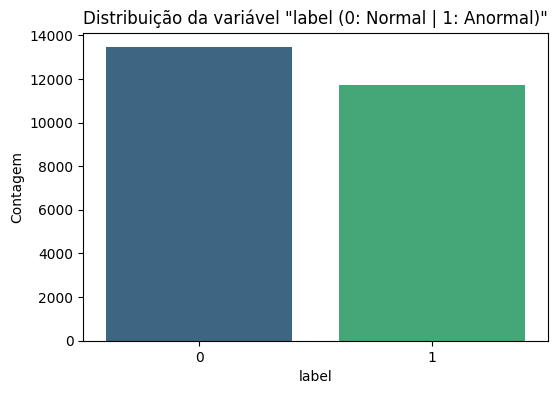

label
0    0.534
1    0.466
Name: proportion, dtype: float64


In [14]:
# Plota um gráfico de distribuição do Alvo (y) "attack_detected"
plt.figure(figsize=(6, 4))
sns.countplot(x='label', hue='label', data=df, palette='viridis', legend=False)
plt.title('Distribuição da variável \"label (0: Normal | 1: Anormal)\"')
plt.xlabel('label')
plt.ylabel('Contagem')
plt.show()

print(df['label'].value_counts(normalize=True).round(3))

In [15]:
# Reduz as features do dataset para 20 -> Verificação foi relizada no final do primeiro teste + Classificação 'label'

#columns = ['src_bytes', 'dst_bytes', 'diff_srv_rate', 'difficulty_level', 'same_srv_rate', 'dst_host_srv_count', 'flag', 'dst_host_same_srv_rate', 'serror_rate', 'dst_host_diff_srv_rate', 'protocol_type', 'logged_in', 'dst_host_srv_serror_rate', 'count', 'dst_host_same_src_port_rate', 'service', 'srv_count', 'dst_host_count', 'dst_host_serror_rate', 'dst_host_srv_diff_host_rate', 'label']


columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised',
       'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'label']

df = df[columns]
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,label
0,0,1,19,9,491,0,0,0,0,0,2,2,0.0,0.0,0.0,0
1,0,2,41,9,146,0,0,0,0,0,13,1,0.0,0.0,0.0,0
2,0,1,46,5,0,0,0,0,0,0,123,6,1.0,1.0,0.0,1
3,0,1,22,9,232,8153,0,0,1,0,5,5,0.2,0.2,0.0,0
4,0,1,22,9,199,420,0,0,1,0,30,32,0.0,0.0,0.0,0


In [16]:
# Define as featureas/colunas de treinamento (X) e a feature/coluna de classificação (y)
X = df.drop(['label'], axis=1)
y = df['label']

In [17]:
# Particiona o dataset em 70% para treinamento e 30% para teste, use o parâmetro "stratify" para assegurar uma proporção igual da classe "y" ("attack_detected") em cada conjunto (Treinamento e Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [18]:
X_train

,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,srv_serror_rate,rerror_rate
8057,0,1,22,9,316,292,0,0,1,0,8,8,0.0,0.0,0.0
15186,0,1,46,5,0,0,0,0,0,0,95,4,1.0,1.0,0.0
10147,0,2,11,9,43,74,0,0,0,0,310,310,0.0,0.0,0.0
5269,0,1,5,5,0,0,0,0,0,0,101,1,1.0,1.0,0.0
17008,0,1,23,1,0,0,0,0,0,0,119,6,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8922,0,1,15,1,0,0,0,0,0,0,126,9,0.0,0.0,1.0
7592,0,2,11,9,44,126,0,0,0,0,70,150,0.0,0.0,0.0
25054,0,1,46,5,0,0,0,0,0,0,170,1,1.0,1.0,0.0
8682,0,1,22,9,243,1493,0,0,1,0,3,3,0.0,0.0,0.0


In [19]:
y_train

8057     0
15186    1
10147    0
5269     1
17008    1
        ..
8922     1
7592     0
25054    1
8682     0
12162    1
Name: label, Length: 17634, dtype: int64

# **Treinamento, Avaliação e Explicabilidade do modelo via SHAP**

In [20]:
# Define a lista de algoritmos de classificação que serão utilizados para treinar o modelo
models = {
    #'Logistic Regression': LogisticRegression(max_iter=1000),
    #'KNN': KNeighborsClassifier(),
    #'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    #'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    #'MLP': MLPClassifier(max_iter=500)
}

In [21]:
# Seleciona uma amostra aleatória do conjunto de teste (X_test), limitada a no máximo 200 linhas para ser utilizado no SHAP
sample_idx = np.random.choice(X_test.index, size=min(200, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]

In [22]:
for name, model in models.items():
    print(f"\n🔍 Treinamento do modelo utilizando o algorítmo {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))



🔍 Treinamento do modelo utilizando o algorítmo Random Forest...
✅ Acurácia: 0.9964
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4035
           1       1.00      0.99      1.00      3523

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558



In [23]:
# Verifica as 20 features/colunas mais importantes

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

top_features = importance.head(20).index.tolist()
print(top_features)

['src_bytes', 'dst_bytes', 'flag', 'count', 'serror_rate', 'service', 'protocol_type', 'logged_in', 'srv_serror_rate', 'srv_count', 'hot', 'rerror_rate', 'duration', 'num_compromised', 'wrong_fragment']


📊 Explicação SHAP para Random Forest


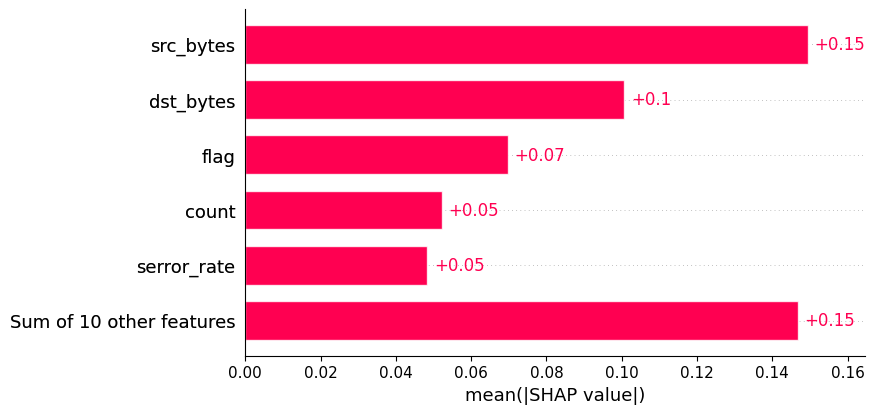

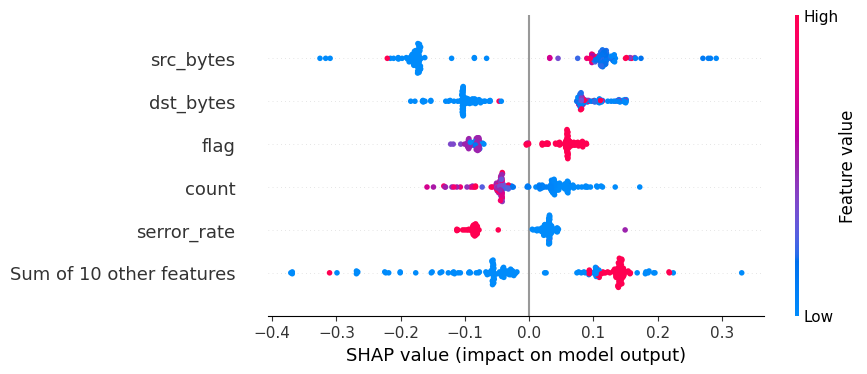

In [24]:
print(f"📊 Explicação SHAP para {name}")

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)
shap.plots.bar(shap_values[...,0], max_display=6)
shap.plots.beeswarm(shap_values[...,0], max_display=6)


# **Explicabilidade do modelo via LIME**

In [27]:
feature_names = list(X_test)
class_names = list(y_test.unique())

print(f"📊 Explicação LIME para {name}")

# Cria um objeto do tipo LIME para explicabilidade (Explicabilidade local)
# Para isso o LIME precisa ter acesso aos dados de treinamento e aos nomes das features e alvo
explainer_l = lime_tabular.LimeTabularExplainer(
    X_test.values, # Convert DataFrame to NumPy array
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    verbose=True
)

# Escolhe uma instância qualquer dos dados para gerar a explicabilidade (Ex: 100)
i = 10
instance_to_explain = X_test.iloc[i].values
# Gera a explicação para a instância escolhida
# A função predict_proba do modelo é passada para o LIME
exp = explainer_l.explain_instance(
    instance_to_explain,
    model.predict_proba,
    num_features= 6 # Número de features a ser considerada para a explicação
)

# Visualização da explicação via LIME
actual_class_label = y_test.iloc[i]
predicted_class_label = model.predict(instance_to_explain.reshape(1, -1))[0]

print(f"Classificação real: {actual_class_label}")
print(f"Classificação prevista: {predicted_class_label}")

print("\nExplanation details:")
print(exp.as_list())
# exp.show_in_notebook(show_table=True)

📊 Explicação LIME para Random Forest
Intercept 0.2148625714799498
Prediction_local [0.74810237]
Right: 1.0
Classificação real: 1
Classificação prevista: 1

Explanation details:
[('src_bytes <= 0.00', 0.2419749300404059), ('dst_bytes <= 0.00', 0.12193148093506444), ('logged_in <= 0.00', 0.10010254275028999), ('rerror_rate <= 0.00', -0.09239308621027804), ('count > 143.00', 0.08438215090625945), ('flag <= 5.00', 0.07724177868096552)]


/home/beloin/Documents/pos-grad/masters/soc_xai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/beloin/Documents/pos-grad/masters/soc_xai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **Explicabilidade do modelo via LLM (GPT-5)**

In [ ]:
# Informa a chave da API da OpenAI
# client = OpenAI(api_key="chave dae API aqui")
client = OpenAI(
    base_url="http://localhost:11434/v1",
    timeout=None 
)


In [29]:
# ==========================
# DESCRIÇÃO DAS COLUNAS
# ==========================
column_description = {
    "duration": "Duração da conexão em segundos",
    "protocol_type": "Protocolo da conexão, podendo ser TCP, UDP ou ICMP",
    "service": "Tipo de serviço de rede acessado (ex: http, ftp, smtp)",
    "flag": "Estado da conexão (indicador de sucesso, rejeição, reset, etc.)",
    "src_bytes": "Quantidade de bytes enviados pelo host de origem",
    "dst_bytes": "Quantidade de bytes enviados pelo host de destino",
    "land": "Indica se a conexão é do tipo land (mesmo IP e porta de origem e destino): sim (1) ou não (0)",
    "wrong_fragment": "Número de fragmentos de pacotes incorretos",
    "urgent": "Número de pacotes com flag urgente ativada",
    "hot": "Número de eventos ‘hot’ na conexão (acessos sensíveis ou suspeitos)",
    "num_failed_logins": "Número de tentativas de login que falharam",
    "logged_in": "Indica se o usuário conseguiu logar na máquina: sim (1) ou não (0)",
    "num_compromised": "Número de arquivos comprometidos na máquina alvo",
    "root_shell": "Indica se foi obtido acesso root: sim (1) ou não (0)",
    "su_attempted": "Indica se houve tentativa de uso do comando 'su' para troca de usuário",
    "num_root": "Número de acessos com privilégios de root",
    "num_file_creations": "Número de operações de criação de arquivos",
    "num_shells": "Número de shells abertos durante a sessão",
    "num_access_files": "Número de operações de acesso a arquivos (ex: leitura/escrita)",
    "num_outbound_cmds": "Número de comandos outbound em uma sessão FTP (normalmente 0 no dataset)",
    "is_host_login": "Indica se o login pertence a uma lista de hosts confiáveis: sim (1) ou não (0)",
    "is_guest_login": "Indica se o login foi feito como convidado (guest): sim (1) ou não (0)",
    "count": "Número de conexões do mesmo tipo na última janela de tempo",
    "srv_count": "Número de conexões do mesmo serviço na última janela de tempo",
    "serror_rate": "Proporção de conexões com erros de TCP em relação ao total",
    "srv_serror_rate": "Proporção de conexões com erros de TCP no mesmo serviço",
    "rerror_rate": "Proporção de conexões com erros de protocolo de rede",
    "srv_rerror_rate": "Proporção de conexões com erros de protocolo no mesmo serviço",
    "same_srv_rate": "Proporção de conexões para o mesmo serviço",
    "diff_srv_rate": "Proporção de conexões para serviços diferentes",
    "srv_diff_host_rate": "Proporção de conexões para o mesmo serviço em diferentes hosts",
    "dst_host_count": "Número de conexões para o mesmo host de destino",
    "dst_host_srv_count": "Número de conexões para o mesmo serviço no host de destino",
    "dst_host_same_srv_rate": "Proporção de conexões para o mesmo serviço no host de destino",
    "dst_host_diff_srv_rate": "Proporção de conexões para serviços diferentes no host de destino",
    "dst_host_same_src_port_rate": "Proporção de conexões para o host de destino usando a mesma porta de origem",
    "dst_host_srv_diff_host_rate": "Proporção de conexões para o mesmo serviço em diferentes hosts de destino",
    "dst_host_serror_rate": "Proporção de conexões com erros TCP para o host de destino",
    "dst_host_srv_serror_rate": "Proporção de conexões com erros TCP no mesmo serviço para o host de destino",
    "dst_host_rerror_rate": "Proporção de conexões com erros de protocolo para o host de destino",
    "dst_host_srv_rerror_rate": "Proporção de conexões com erros de protocolo no mesmo serviço para o host de destino",
    "label": "Classe da conexão, podendo ser: normal (0) ou anormal (1)"
}

# ==========================
# EQUIVALÊNCIA CATEGORIA -> CÓDIGO NUMÉRICO DAS COLUNAS
# ==========================
category_encoding = {
    "protocol_type": {
        "ICMP": 0,
        "TCP": 1,
        "UDP": 2
    },

    "service": {
        "IRC": 0,
        "X11": 1,
        "Z39_50": 2,
        "auth": 3,
        "bgp": 4,
        "courier": 5,
        "csnet_ns": 6,
        "ctf": 7,
        "daytime": 8,
        "discard": 9,
        "domain": 10,
        "domain_u": 11,
        "echo": 12,
        "eco_i": 13,
        "ecr_i": 14,
        "efs": 15,
        "exec": 16,
        "finger": 17,
        "ftp": 18,
        "ftp_data": 19,
        "gopher": 20,
        "hostnames": 21,
        "http": 22,
        "http_443": 23,
        "http_8001": 24,
        "imap4": 25,
        "iso_tsap": 26,
        "klogin": 27,
        "kshell": 28,
        "ldap": 29,
        "link": 30,
        "login": 31,
        "mtp": 32,
        "name": 33,
        "netbios_dgm": 34,
        "netbios_ns": 35,
        "netbios_ssn": 36,
        "netstat": 37,
        "nnsp": 38,
        "nntp": 39,
        "ntp_u": 40,
        "other": 41,
        "pm_dump": 42,
        "pop_2": 43,
        "pop_3": 44,
        "printer": 45,
        "private": 46,
        "red_i": 47,
        "remote_job": 48,
        "rje": 49,
        "shell": 50,
        "smtp": 51,
        "sql_net": 52,
        "ssh": 53,
        "sunrpc": 54,
        "supdup": 55,
        "systat": 56,
        "telnet": 57,
        "tim_i": 58,
        "time": 59,
        "urh_i": 60,
        "urp_i": 61,
        "uucp": 62,
        "uucp_path": 63,
        "vmnet": 64,
        "whois": 65
    },

    "flag": {
        "OTH": 0,
        "REJ": 1,
        "RSTO": 2,
        "RSTOS0": 3,
        "RSTR": 4,
        "S0": 5,
        "S1": 6,
        "S2": 7,
        "S3": 8,
        "SF": 9,
        "SH": 10
    },

    "label": {
        "normal": 0,
        "anormal": 1
    }
}

# Estatísticas do Dataset
stats = df.describe(include="all").to_string()

# Amostra dos dados de treinamento
train_sample = X_train.sample(50)
train_sample["label"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

# Amostra das previsões vs real
pred_sample = pd.DataFrame({
    "real": y_test,
    "predicted": y_pred
})

pred_sample_json = pred_sample.sample(50).to_json(orient="records")

# ==========================
# INFORMAÇÕES DO MODELO
# ==========================
model_info = {
    "model_type": "Random Forest",
    "task": "Detecção de intrusão a partir de log. Cada entrada do log é classificada como: Normal (0) ou Anormal (1)",
    "target_variable": "label",
    "features": list(X.columns)
}

In [30]:
# ==========================
# PROMPT PARA O LLM
# ==========================
prompt = f"""
Você é especialista em Inteligência Artificial Explicável (XAI) e Segurança Cibernética.
Sua tarefa é analisar um modelo de aprendizado de máquina treinado e fornecer uma explicação detalhada de seu comportamento.

=========================
INFORMAÇÕES DO MODELO
=========================
{model_info}

=========================
DESCRIÇÃO DAS COLUNAS
=========================
{column_description}

=========================
CODIFICAÇÃO: CATEGORIA → VALOR NUMÉRICO
=========================
{category_encoding}

=========================
ESTATÍTISCA DO DATASET
=========================
{stats}

=========================
AMOSTRA DOS DADOS DE TREINAMENTO
=========================
{train_sample_json}

=========================
AMOSTRA DA CLASSIFICAÇÃO REAL vs CLASSIFICAÇÃO DO MODELO
=========================
{pred_sample_json}

=========================
TAREFA
=========================

Forneça uma análise detalhada da explicabilidade do modelo, incluindo:

1. Interpretação global e local do comportamento do modelo.
2. Quais características parecem ser mais influentes na previsão de classificação label: Normal (0) ou Anormal (1)
3. Identifique possíveis padrões ou correlações no conjunto de dados.
4. Analise a amostra de previsão e comente sobre possíveis classificações incorretas.
5. Explique como as codificações categóricas podem influenciar o comportamento do modelo.
6. Forneça insights de segurança cibernética com base nos padrões detectados nos logs.
7. Sugira possíveis melhorias para o modelo ou conjunto de dados.

Sua explicação deve ser técnica, porém clara, estruturada em seções e adequada para um relatório de aprendizado de máquina.
"""

In [31]:
print(prompt)


Você é especialista em Inteligência Artificial Explicável (XAI) e Segurança Cibernética.
Sua tarefa é analisar um modelo de aprendizado de máquina treinado e fornecer uma explicação detalhada de seu comportamento.

INFORMAÇÕES DO MODELO
{'model_type': 'Random Forest', 'task': 'Detecção de intrusão a partir de log. Cada entrada do log é classificada como: Normal (0) ou Anormal (1)', 'target_variable': 'label', 'features': ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate']}

DESCRIÇÃO DAS COLUNAS
{'duration': 'Duração da conexão em segundos', 'protocol_type': 'Protocolo da conexão, podendo ser TCP, UDP ou ICMP', 'service': 'Tipo de serviço de rede acessado (ex: http, ftp, smtp)', 'flag': 'Estado da conexão (indicador de sucesso, rejeição, reset, etc.)', 'src_bytes': 'Quantidade de bytes enviados pelo host de origem', 'dst_bytes': 'Quanti

In [32]:
# ==========================
# CHAMADA DA API
# ==========================
response = client.responses.create(
    model="qwen3.5:cloud",
    input=[
        {
            "role": "system",
            "content": "Você é um especialista em Machine Learning e Explainable AI."
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    max_output_tokens=10000
)

APITimeoutError: Request timed out.

In [ ]:
# ==========================
# RESULTADO
# ==========================

explanation = ""

for item in response.output:
    if item.type == "message":
        for content in item.content:
            if content.type == "output_text":
                explanation += content.text


print("\n===== EXPLICAÇÃO DO MODELO =====\n")
print(explanation)